<a href="https://colab.research.google.com/github/rahilkhan-acadmic/APAIML-GradedMiniProject/blob/develop/capstone/Phase2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 — Exploratory Data Analysis and Data Quality
1. Load data into Python for analysis. Combine them
2. Analyze missing values in approved_amount, payment_days, and length_of_stay_hours.
3. Perform distribution analysis by department, visit_type, insurance_provider, and city.
4. Detect and classify outliers in billed_amount, payment_days, and length_of_stay_hours.
4. Engineer features such as visit frequency, average length of stay per patient, provider rejection rate, days since registration, and time-based features.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Upload file to google.colab
import io
from google.colab import files, drive

drive.mount('/content/drive')

# comment this code, if files already uploaded.
# uploaded = files.upload()

Mounted at /content/drive


### 1. Load data into Python for analysis. Combine them


In [4]:
# Load and read patients, visits & billing csv
patients_df = pd.read_csv('/content/drive/MyDrive/files/capstone/patients.csv')
patients_df.head()

visits_df = pd.read_csv('/content/drive/MyDrive/files/capstone/visits.csv')
visits_df.head()

billing_df = pd.read_csv('/content/drive/MyDrive/files/capstone/billing.csv')
billing_df.head()

,bill_id,visit_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,1,23577.37,0.00,Rejected,16.0,2025-06-18
1,2,2,38178.81,38178.81,Paid,18.0,2025-10-09
2,3,3,5038.97,5038.97,Paid,NaN,2025-01-20
3,4,4,22813.34,22813.34,Paid,16.0,2025-12-24
4,5,5,27106.95,27106.95,Paid,14.0,2025-09-23


### 2. Analyze missing values in approved_amount, payment_days, and length_of_stay_hours.


In [5]:
# Analyze missing values in approved_amount, payment_days, and length_of_stay_hours.
df_merged = pd.merge(patients_df, visits_df, on='patient_id')
df_merged = pd.merge(df_merged, billing_df, on='visit_id')
df_merged.head()


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,4327,2025-10-15,General,ICU,6.39,High,162,4327,26322.05,13938.52,Pending,NaN,2025-11-29
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,OPD,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,OPD,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,ER,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,ER,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26


In [6]:
missing_approved_amount = df_merged['approved_amount'].isna().sum()
print(f"Number of missing values in 'approved_amount': {missing_approved_amount}")

missing_payment_days = df_merged['payment_days'].isna().sum()
print(f"Number of missing values in 'payment_days': {missing_payment_days}")

missing_length_of_stay_hours = df_merged['length_of_stay_hours'].isna().sum()
print(f"Number of missing values in 'missing_length_of_stay_hours': {missing_length_of_stay_hours}")


Number of missing values in 'approved_amount': 1318
Number of missing values in 'payment_days': 790
Number of missing values in 'missing_length_of_stay_hours': 0


In [7]:
missing_approved_amount_percentage = (missing_approved_amount / len(df_merged)) *100
print(f"Percentage of missing values in 'approved_amount': {missing_approved_amount_percentage:.2f}%")

missing_payment_days_percentage = (missing_payment_days/len(df_merged)) * 100
print(f"Percentage of missing values in 'payment_days': {missing_payment_days_percentage:.2f}%")

missing_length_of_stay_hours_percentage = (missing_length_of_stay_hours/len(df_merged)) *100
print(f"Percentage of missing values in 'length_of_stay_hours': {missing_length_of_stay_hours_percentage:.2f}%")

Percentage of missing values in 'approved_amount': 5.27%
Percentage of missing values in 'payment_days': 3.16%
Percentage of missing values in 'length_of_stay_hours': 0.00%


In [8]:
missing_data_dic = {
    'missing_approved_amount': missing_approved_amount,
    'missing_payment_days': missing_payment_days,
    'missing_length_of_stay_hours': missing_length_of_stay_hours
}
missing_data_series = pd.Series(missing_data_dic)
display(missing_data_series.head())

,0
missing_approved_amount,1318
missing_payment_days,790
missing_length_of_stay_hours,0


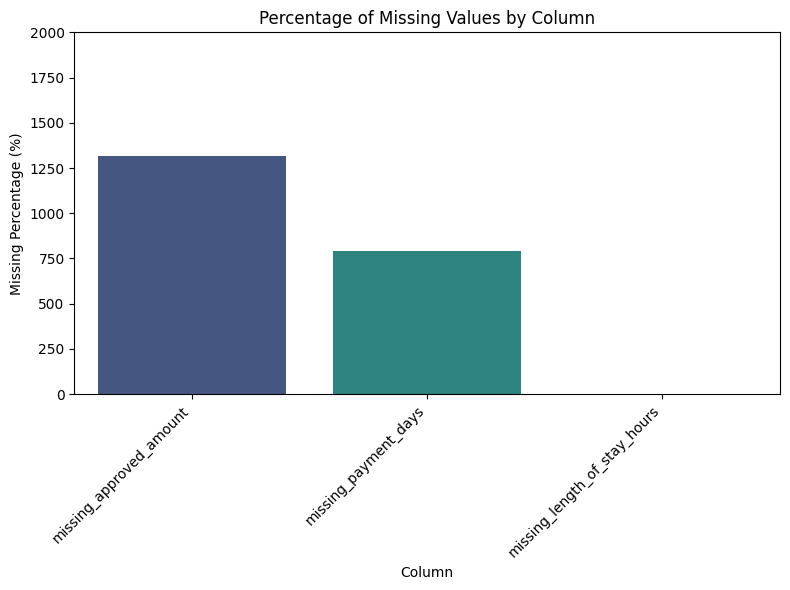

In [9]:
plt.figure(figsize=(8, 6))
sns.barplot(x=missing_data_series.index, y=missing_data_series.values, hue=missing_data_series.index, palette='viridis', legend=False)
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Missing Percentage (%)')
plt.ylim(0, 2000) # Set y-axis limit from 0 to 100
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3. Perform distribution analysis by department, visit_type, insurance_provider, and city.


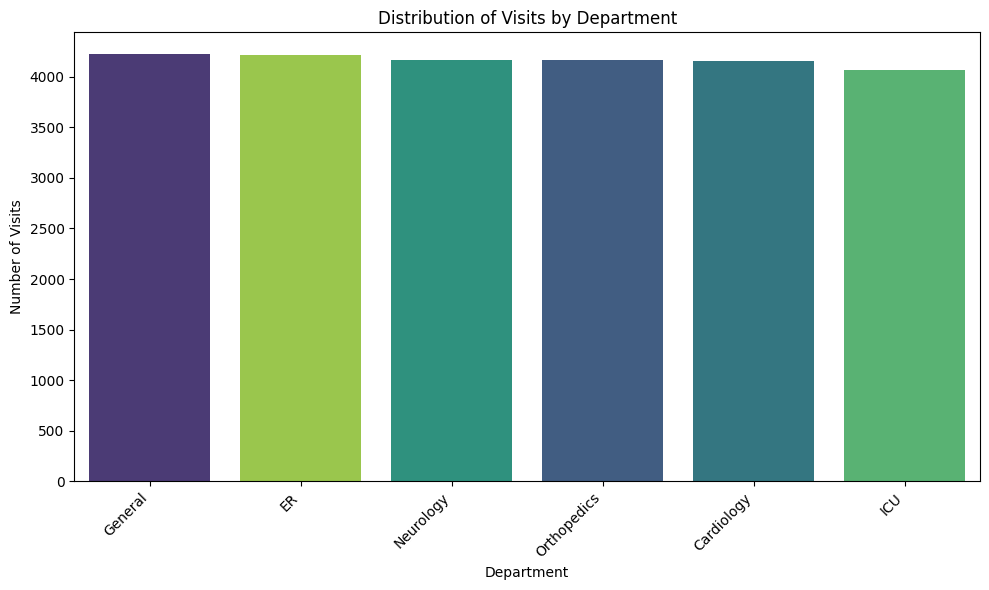

In [10]:
# 1. Distribution by Department
plt.figure(figsize=(10, 6))
sns.countplot(data=df_merged, x='department', hue='department', palette='viridis', legend=False, order=df_merged['department'].value_counts().index)
plt.title('Distribution of Visits by Department')
plt.xlabel('Department')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

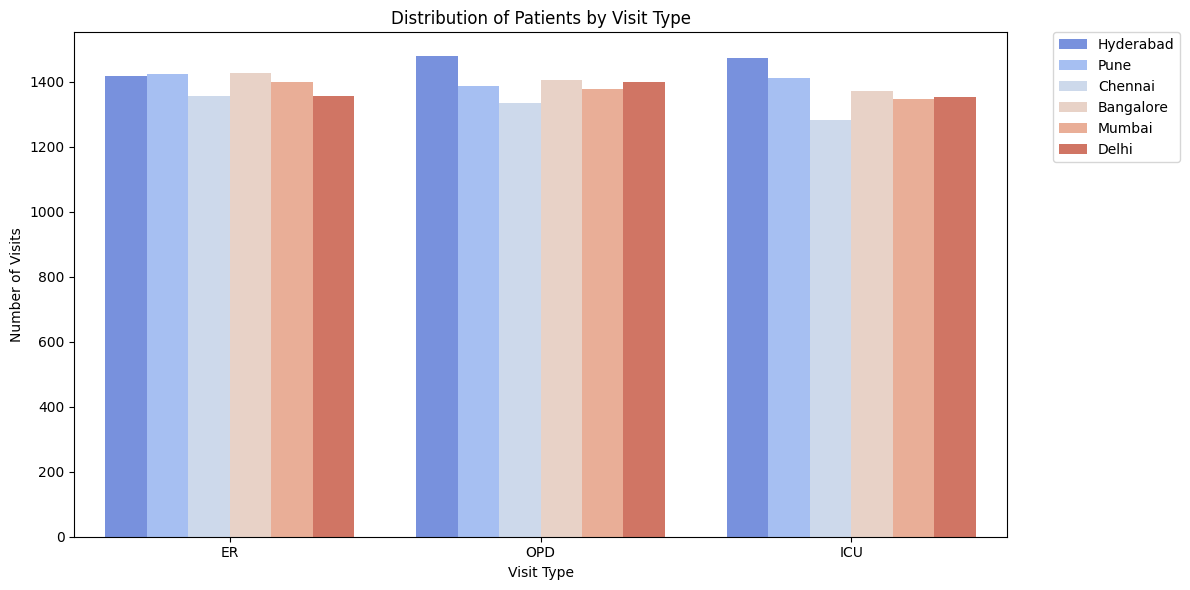

In [11]:
#2. Distribution by visit type
plt.figure(figsize=(12, 6))
sns.countplot(data=df_merged, x='visit_type', hue='city', palette='coolwarm', order=df_merged['visit_type'].value_counts().index)
plt.title('Distribution of Patients by Visit Type')
plt.xlabel('Visit Type')
plt.ylabel('Number of Visits')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

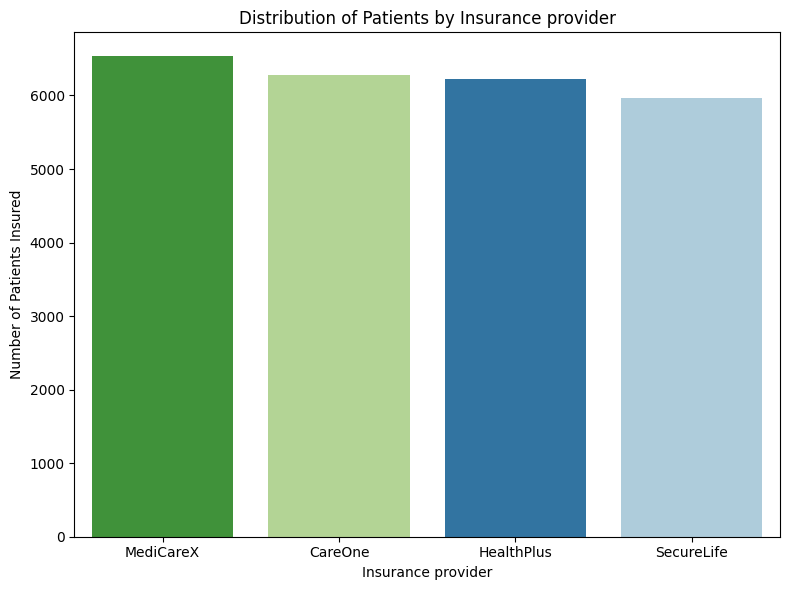

In [12]:
#3. Distribution by Insurance provider
plt.figure(figsize=(8, 6))
sns.countplot(data=df_merged, x='insurance_provider', hue='insurance_provider', palette='Paired', order=df_merged['insurance_provider'].value_counts().index)
plt.title('Distribution of Patients by Insurance provider')
plt.xlabel('Insurance provider')
plt.ylabel('Number of Patients Insured')
plt.tight_layout()
plt.show()

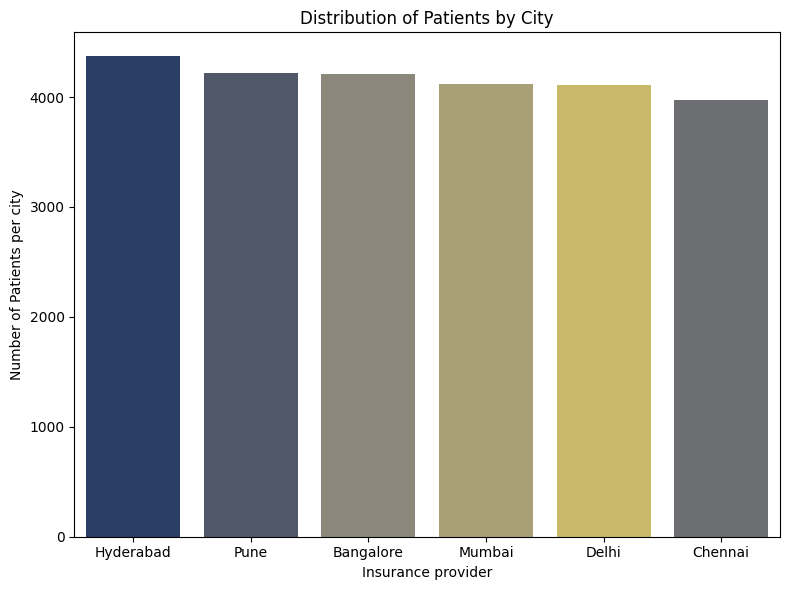

In [13]:
#4. Distribution of patient by City
plt.figure(figsize=(8, 6))
sns.countplot(data=df_merged, x='city', hue='city', palette='cividis', order=df_merged['city'].value_counts().index)
plt.title('Distribution of Patients by City')
plt.xlabel('Insurance provider')
plt.ylabel('Number of Patients per city')
plt.tight_layout()
plt.show()



###4. Detect and classify outliers in billed_amount, payment_days, and length_of_stay_hours.

Detection and classification of outliers in `billed_amount`, `payment_days`, and `length_of_stay_hours` using visualizations and statistical methods.

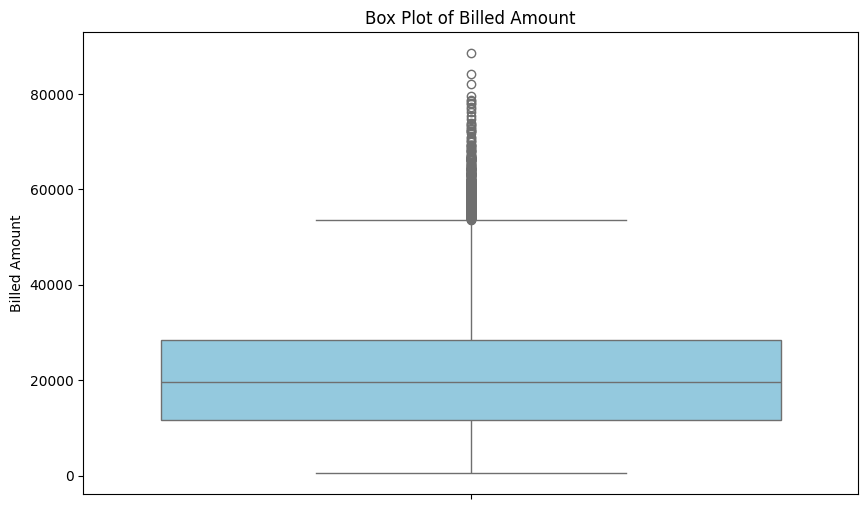

,billed_amount
count,25000.000000
mean,20870.757442
std,12606.285782
min,500.000000
25%,11582.450000
50%,19644.850000
75%,28398.065000
max,88539.010000


In [14]:
# Box plot for billed_amount
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_merged['billed_amount'], color='skyblue')
plt.title('Box Plot of Billed Amount')
plt.ylabel('Billed Amount')
plt.show()

# Describe statistics for billed_amount to see quartiles and min/max
display(df_merged['billed_amount'].describe())

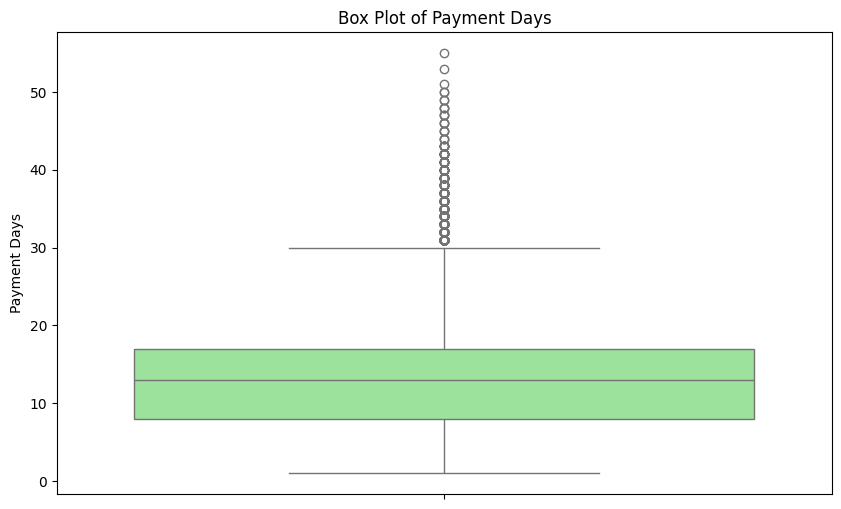

,payment_days
count,24210.000000
mean,13.048079
std,7.237736
min,1.000000
25%,8.000000
50%,13.000000
75%,17.000000
max,55.000000


In [15]:
# Box plot for payment_days
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_merged['payment_days'], color='lightgreen')
plt.title('Box Plot of Payment Days')
plt.ylabel('Payment Days')
plt.show()

# Describe statistics for payment_days
display(df_merged['payment_days'].describe())

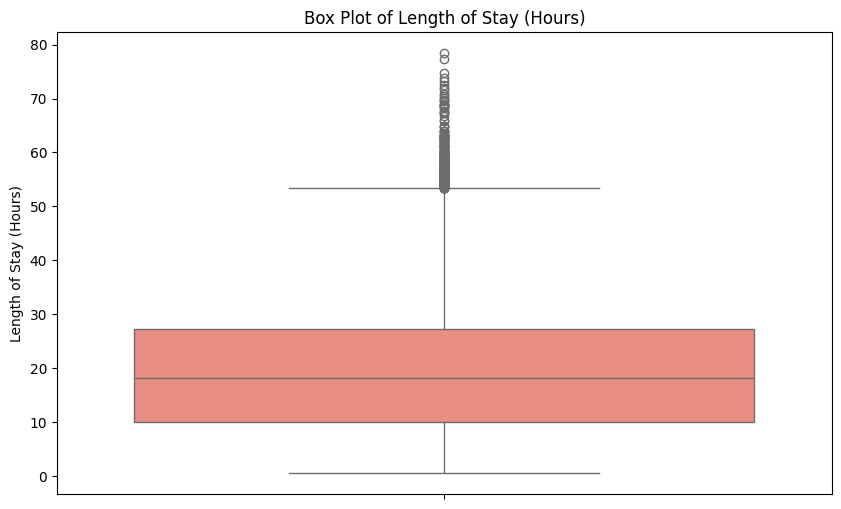

,length_of_stay_hours
count,25000.000000
mean,19.551584
std,12.314004
min,0.500000
25%,9.960000
50%,18.205000
75%,27.312500
max,78.420000


In [16]:
# Box plot for length_of_stay_hours
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_merged['length_of_stay_hours'], color='salmon')
plt.title('Box Plot of Length of Stay (Hours)')
plt.ylabel('Length of Stay (Hours)')
plt.show()

# Describe statistics for length_of_stay_hours
display(df_merged['length_of_stay_hours'].describe())

###5. Engineer features such as visit frequency, average length of stay per patient, provider rejection rate, days since registration, and time-based features.


In [18]:
# Ensure date columns are in datetime format
df_merged['registration_date'] = pd.to_datetime(df_merged['registration_date'])
df_merged['visit_date'] = pd.to_datetime(df_merged['visit_date'])
df_merged['billing_date'] = pd.to_datetime(df_merged['billing_date'])

# 1. Visit Frequency per Patient
visit_frequency = df_merged.groupby('patient_id')['visit_id'].nunique().reset_index()
visit_frequency.rename(columns={'visit_id': 'visit_frequency'}, inplace=True)
df_merged = pd.merge(df_merged, visit_frequency, on='patient_id', how='left')
print("Visit Frequency per Patient (first 5 rows):")
display(df_merged[['patient_id', 'visit_frequency']].head())

# 2. Average Length of Stay per Patient
avg_los_per_patient = df_merged.groupby('patient_id')['length_of_stay_hours'].mean().reset_index()
avg_los_per_patient.rename(columns={'length_of_stay_hours': 'avg_length_of_stay_hours'}, inplace=True)
df_merged = pd.merge(df_merged, avg_los_per_patient, on='patient_id', how='left')
print("\nAverage Length of Stay per Patient (first 5 rows):")
display(df_merged[['patient_id', 'avg_length_of_stay_hours']].head())

# 3. Provider Rejection Rate
total_claims_per_provider = df_merged.groupby('insurance_provider')['bill_id'].count().reset_index()
total_claims_per_provider.rename(columns={'bill_id': 'total_claims'}, inplace=True)

rejected_claims_per_provider = df_merged[df_merged['claim_status'] == 'Rejected'].groupby('insurance_provider')['bill_id'].count().reset_index()
rejected_claims_per_provider.rename(columns={'bill_id': 'rejected_claims'}, inplace=True)

provider_rejection = pd.merge(total_claims_per_provider, rejected_claims_per_provider, on='insurance_provider', how='left')
provider_rejection['rejected_claims'] = provider_rejection['rejected_claims'].fillna(0)
provider_rejection['rejection_rate'] = (provider_rejection['rejected_claims'] / provider_rejection['total_claims']) * 100
df_merged = pd.merge(df_merged, provider_rejection[['insurance_provider', 'rejection_rate']], on='insurance_provider', how='left')
print("\nProvider Rejection Rate (first 5 rows):")
display(df_merged[['insurance_provider', 'rejection_rate']].head())

# 4. Days Since Registration for each visit
df_merged['days_since_registration'] = (df_merged['visit_date'] - df_merged['registration_date']).dt.days
print("\nDays Since Registration (first 5 rows):")
display(df_merged[['patient_id', 'registration_date', 'visit_date', 'days_since_registration']].head())

# 5. Time-based Features from visit_date
df_merged['visit_year'] = df_merged['visit_date'].dt.year
df_merged['visit_month'] = df_merged['visit_date'].dt.month
df_merged['visit_day'] = df_merged['visit_date'].dt.day
df_merged['visit_day_of_week'] = df_merged['visit_date'].dt.dayofweek # Monday=0, Sunday=6
df_merged['visit_quarter'] = df_merged['visit_date'].dt.quarter
print("\nTime-based Features (first 5 rows):")
display(df_merged[['visit_date', 'visit_year', 'visit_month', 'visit_day', 'visit_day_of_week', 'visit_quarter']].head())

Visit Frequency per Patient (first 5 rows):


,patient_id,visit_frequency
0,1,6
1,1,6
2,1,6
3,1,6
4,1,6



Average Length of Stay per Patient (first 5 rows):


,patient_id,avg_length_of_stay_hours
0,1,22.183333
1,1,22.183333
2,1,22.183333
3,1,22.183333
4,1,22.183333



Provider Rejection Rate (first 5 rows):


,insurance_provider,rejection_rate
0,SecureLife,15.691534
1,SecureLife,15.691534
2,SecureLife,15.691534
3,SecureLife,15.691534
4,SecureLife,15.691534



Days Since Registration (first 5 rows):


,patient_id,registration_date,visit_date,days_since_registration
0,1,2025-05-14,2025-10-15,154
1,1,2025-05-14,2025-09-21,130
2,1,2025-05-14,2025-02-09,-94
3,1,2025-05-14,2025-10-09,148
4,1,2025-05-14,2025-07-07,54



Time-based Features (first 5 rows):


,visit_date,visit_year,visit_month,visit_day,visit_day_of_week,visit_quarter
0,2025-10-15,2025,10,15,2,4
1,2025-09-21,2025,9,21,6,3
2,2025-02-09,2025,2,9,6,1
3,2025-10-09,2025,10,9,3,4
4,2025-07-07,2025,7,7,0,3
